# Coursea public data 
Coursera public data is sourced from https://github.com/elleros/courseraforums

To get a copy of the data go to https://raw.githubusercontent.com/elleros/courseraforums/master/data/course_posts.csv 

In [2]:
import pandas as pd
import numpy as np
import os

## Get and Clean Data

First we will coerce our data into a pandas dataframe

We haven't done any cleaning yet

In [3]:
# Set data directory for path
data_dir = '.data'

# Set seed 
np.random.seed(0)

# Read in csv
# pdf_course_posts = pd.read_csv(os.path.join(data_dir, 'course_posts.csv'))

# Read data in directly from hosted location
pdf_course_posts = pd.read_csv("https://raw.githubusercontent.com/elleros/courseraforums/master/data/course_posts.csv")

# View a sample
pdf_course_posts.sample(5)

,post_id,thread_id,course_id,parent_id,order,user_id,user_type,post_time,relative_t,votes,num_words,forum_id
657052,7720,2807,startup-001,14124,0,2691845793,Student,1372801009,0.189292,0,6,8
386422,37233,5530,lead-ei-001,0,39,1723497250,Student,1369382936,0.555703,0,32,24
435856,706,263,ml-003,2026,0,7147482790,Student,1366749663,0.026598,0,19,10
488167,1684,366,nlangp-001,0,1,2416535990,Student,1363278378,0.409785,0,92,3
557515,5628,346,programming1-002,0,50,3151471734,Student,1377798801,0.219294,0,12,4


## Now we're going to take a look at the shape of the data

First we will look at the length of the posts

If we look at a histogram of the number of words it looks like we have some outliers

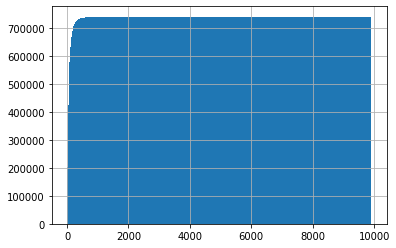

In [8]:
# Take just the length of the words
post_lengths = pdf_course_posts.loc[:, 'num_words']

# Lets look at a histogram
post_lengths.hist(bins=1000, cumulative=True)

Below, we take everything underneath a certain maximum length and try to look at the underlying distribution.

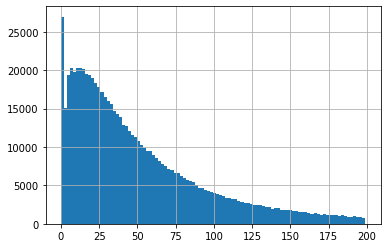

In [5]:
max_len = 200

# Make a mask
sub_max_mask = post_lengths < max_len

post_lengths[sub_max_mask].hist(bins=int(max_len/2))

Let's look at the frequency of posts per user type.

We observe that student and anonymous posts make up most of the posts

In [6]:
# Make a group by object
gb_user = pdf_course_posts.groupby('user_type')

# Lets look at the percentage of posts that each group makes up
gb_user.count()['post_id']/len(pdf_course_posts)

user_type
Anonymous                0.095432
Community TA             0.023456
Coursera Staff           0.000219
Coursera Tech Support    0.000308
Instructor               0.010984
Staff                    0.016218
Student                  0.853383
Name: post_id, dtype: float64

In [7]:
# Create alias
df = pdf_course_posts

# Find percentage of posts for each course
course_enrollement = df.groupby("course_id")["thread_id"].sum().sort_values(ascending=False) 
(course_enrollement / course_enrollement.sum() * 100).iloc[:10]

course_id
lead-ei-001               23.071325
intropsych-001            18.523565
startup-001               10.036865
ml-003                     6.816921
videogameslearning-001     6.639007
datasci-001                5.528766
humankind-001              4.636898
programming1-002           4.030665
blendedlearning-001        3.483146
stats1-002                 2.230001
Name: thread_id, dtype: float64